Training Neural Network for Traffic Demand Prediction...
Epoch 1/15


C:\Users\woons\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2908.7942 - mae: 2908.7942 - val_loss: 2113.9365 - val_mae: 2113.9365
Epoch 2/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1188.1711 - mae: 1188.1711 - val_loss: 870.8839 - val_mae: 870.8839
Epoch 3/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 849.9420 - mae: 849.9420 - val_loss: 793.9510 - val_mae: 793.9510
Epoch 4/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 787.1512 - mae: 787.1512 - val_loss: 734.5396 - val_mae: 734.5396
Epoch 5/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 733.7293 - mae: 733.7293 - val_loss: 675.9324 - val_mae: 675.9324
Epoch 6/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 686.5673 - mae: 686.5673 - val_loss: 636.6685 - val_mae: 636.6685
Epoch 7/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 659.3487 - mae: 659.3487 - val_loss: 610.6388 - val_mae: 610.6388
Epoch 8/15
482/482 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 635.6210 - mae: 635.6210 - val_loss: 584.2539 - val_mae: 584.25

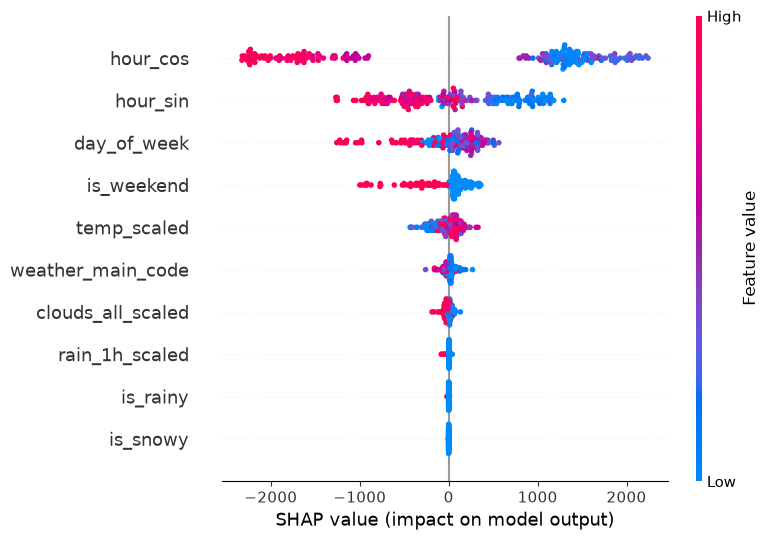

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import shap

# 1. Load Data
df = pd.read_csv("C:/Users/woons/Documents/smart-city-traffic-capstone/part 3_machine_learning/data/features_traffic_proxy.csv")

# 2. Define Features and Target (Predicting traffic_volume)
features = [
    'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 
    'temp_scaled', 'rain_1h_scaled', 'clouds_all_scaled',       
    'weather_main_code', 'is_rainy', 'is_snowy'
]

X = df[features].fillna(0)
y = df['traffic_volume']

# Scale features for Neural Network stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# 3. BUILD & TRAIN NEURAL NETWORK (Demand Prediction)
# ==========================================
print("Training Neural Network for Traffic Demand Prediction...")
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Linear output for continuous traffic volume regression
])

nn_model.compile(optimizer='adam', loss='mae', metrics=['mae'])

# Train the model
history = nn_model.fit(
    X_train, y_train, 
    validation_split=0.2, 
    epochs=15, 
    batch_size=64, 
    verbose=1
)

# Evaluate on Test Set
nn_loss, nn_mae = nn_model.evaluate(X_test, y_test, verbose=0)
print(f"\nNeural Network Test MAE: {nn_mae:.2f}")


# ==========================================
# 4. EXPLAINABILITY USING SHAP (Via Proxy Tree Model)
# ==========================================
print("\nGenerating SHAP Explanations...")

rf_proxy = RandomForestRegressor(n_estimators=50, random_state=42)
rf_proxy.fit(X_train, y_train)

# Initialize SHAP Tree Explainer
explainer = shap.TreeExplainer(rf_proxy)
# Take a smaller sample of X_test for fast SHAP value computation
shap_values = explainer.shap_values(X_test[:200])

print("SHAP explanation values successfully computed for feature attributions.")
print("You can plot summary plots using: shap.summary_plot(shap_values, X_test[:200], feature_names=features)")
print(f"Training Complete! Neural Network Test MAE: {nn_mae:.2f}")
shap.summary_plot(shap_values, X_test[:200], feature_names=features)